In [36]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import relu,linear
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)



tf.keras.backend.set_floatx('float64')


tf.autograph.set_verbosity(0)

In [13]:
X = np.array([
    [3, 5, 2, 3, 1, 5, 4, 0],
    [3, 5, 3, 3, 1, 4, 4, 0],
    [3, 4, 3, 3, 1, 5, 3, 1],
    [2, 5, 0, 0, 0, 1, 3, 0],
    [3, 4, 2, 1, 1, 2, 3, 0],
    [3, 5, 2, 2, 1, 4, 3, 0],
    [2, 5, 2, 0, 0, 2, 3, 0],
    [3, 5, 3, 1, 1, 3, 2, 0],
    [3, 4, 2, 2, 1, 5, 5, 0],
    [3, 5, 3, 1, 1, 4, 5, 0],
    [2, 5, 2, 1, 1, 5, 5, 0],
    [3, 4, 2, 0, 0, 2, 3, 0],
    [1, 3, 0, 0, 0, 1, 3, 0],
    [3, 3, 2, 1, 1, 2, 2, 0],
    [3, 4, 3, 3, 1, 5, 5, 0],
    [3, 5, 3, 3, 1, 5, 5, 1],
    [3, 5, 3, 3, 1, 5, 5, 0],
    [3, 5, 3, 3, 1, 5, 5, 0],
    [2, 5, 0, 0, 0, 4, 3, 0]
])

y = np.array([
    1, 1, 1, 0, 0, 1, 0, 0, 1,
    1, 1, 0, 0, 0, 1, 1, 1, 1, 0
])


print("X.shape", X.shape, "y.shape", y.shape)

X.shape (19, 8) y.shape (19,)


In [14]:
X_train, X_, y_train, y_ = train_test_split(X,y,test_size=0.40, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_,y_,test_size=0.50, random_state=1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_cv.shape", X_cv.shape, "y_cv.shape", y_cv.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape)

X_train.shape (11, 8) y_train.shape (11,)
X_cv.shape (4, 8) y_cv.shape (4,)
X_test.shape (4, 8) y_test.shape (4,)


In [15]:
dscaler = StandardScaler()
X_train = dscaler.fit_transform(X_train)
X_cv = dscaler.transform(X_cv)
X_test = dscaler.transform(X_test)

In [16]:
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

tf.random.set_seed(1234)
model = Sequential(
    [
        tf.keras.layers.Dense(4, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.5)),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ], name="Sponsor"
)
model.compile(
    loss=BinaryCrossentropy,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

In [18]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
]

In [20]:
training = model.fit(
    X_train, y_train,
    validation_data = (X_cv, y_cv),
    epochs=500,
    callbacks=callbacks,
    verbose=2,
    batch_size=8,
)

Epoch 1/500
2/2 - 4s - 2s/step - accuracy: 0.1818 - auc: 0.2000 - loss: 3.0665 - val_accuracy: 0.2500 - val_auc: 1.0000 - val_loss: 2.7513
Epoch 2/500
2/2 - 0s - 185ms/step - accuracy: 0.0909 - auc: 0.2000 - loss: 2.8554 - val_accuracy: 0.2500 - val_auc: 1.0000 - val_loss: 2.5538
Epoch 3/500
2/2 - 0s - 62ms/step - accuracy: 0.1818 - auc: 0.2000 - loss: 2.6610 - val_accuracy: 0.2500 - val_auc: 1.0000 - val_loss: 2.3684
Epoch 4/500
2/2 - 0s - 44ms/step - accuracy: 0.1818 - auc: 0.2000 - loss: 2.4789 - val_accuracy: 0.5000 - val_auc: 1.0000 - val_loss: 2.1945
Epoch 5/500
2/2 - 0s - 68ms/step - accuracy: 0.1818 - auc: 0.2000 - loss: 2.3087 - val_accuracy: 0.5000 - val_auc: 1.0000 - val_loss: 2.0329
Epoch 6/500
2/2 - 0s - 88ms/step - accuracy: 0.1818 - auc: 0.2167 - loss: 2.1507 - val_accuracy: 0.5000 - val_auc: 1.0000 - val_loss: 1.8844
Epoch 7/500
2/2 - 0s - 46ms/step - accuracy: 0.1818 - auc: 0.2667 - loss: 2.0044 - val_accuracy: 0.5000 - val_auc: 1.0000 - val_loss: 1.7497
Epoch 8/500
2/

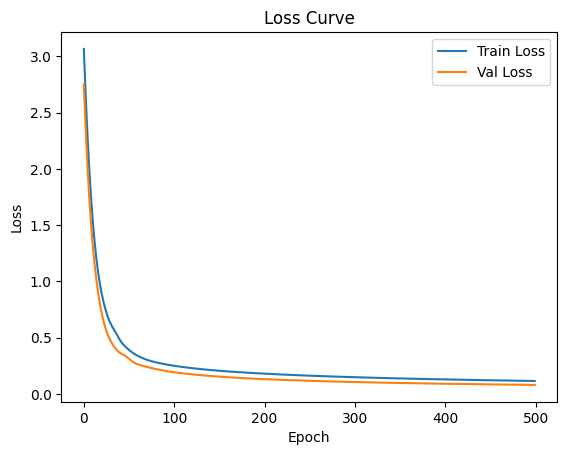

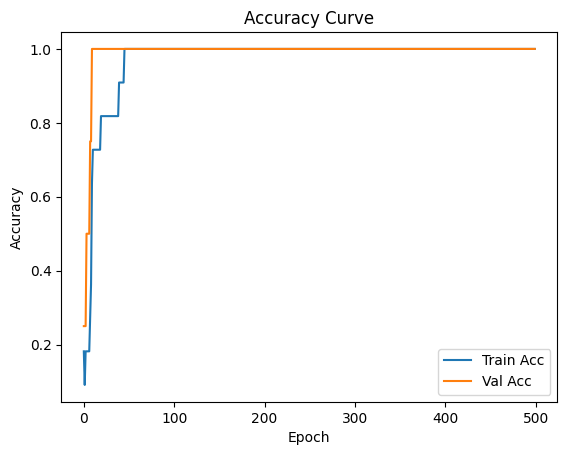

In [21]:
def plot_history(h):
    plt.figure()
    plt.plot(h.history['loss'], label='Train Loss')
    plt.plot(h.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss Curve'); plt.show()

    plt.figure()
    plt.plot(h.history['accuracy'], label='Train Acc')
    plt.plot(h.history['val_accuracy'], label='Val Acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy Curve'); plt.show()

plot_history(training)

In [7]:
def eval_cat_err(y, yhat):
    m = len(y)
    incorrect = 0
    for i in range(m):
        if(yhat[i]!=y[i]):
            incorrect+=1

    cerr=incorrect/m
    return(cerr)

In [22]:
def model_predict(X):
  Y_hat = model.predict(X).flatten()
  for i in range (len(Y_hat)):
    if Y_hat[i]>0.5:
      Y_hat[i]=1
    else:
      Y_hat[i]=0
  return Y_hat

In [23]:
training_cerr_complex = eval_cat_err(y_train, model_predict(X_train))
cv_cerr_complex = eval_cat_err(y_cv, model_predict(X_cv))
test_cerr_complex = eval_cat_err(y_test, model_predict(X_test))
print(f"categorization error, training, complex model: {training_cerr_complex:0.3f}")
print(f"categorization error, cv,       complex model: {cv_cerr_complex:0.3f}")
print(f"categorization error, test,       complex model: {test_cerr_complex:0.3f}")
labels = ['Train Error', 'CV Error']
errors = [training_cerr_complex, cv_cerr_complex]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
categorization error, training, complex model: 0.000
categorization error, cv,       complex model: 0.000
categorization error, test,       complex model: 0.000


In [37]:
X_uji=np.zeros((1, 8), dtype=int)
question = ["Frekuensi hadir dalam CG dalam 3 bulan terakhir (0-3)",
            "Dinilai dari sikap jujur, bertanggung jawab, dan tidak membuat konflik (1-5)",
            "Keaktifan dalam pelayanan lain di gereja (0-3)",
            "Pernah memimpin sharing/doa atau menunjukkan potensi memimpin (0-3)",
            "Sudah mengikuti CGT (0/1)",
            "Inisiatif jika melihat kebutuhan dalam CG (1-5)",
            "Disenangi, mudah bergaul, membangun, tidak terlalu dominan/pasif (1-5)",
            "Memiliki pacar (0/1)"
            ]
for i in range (8):
  while True:
        try:
            s = input(question[i] + ": ")
            X_uji[0][i] = int(s)
            break
        except ValueError:
            print("Input tidak valid, masukkan angka.")
print("\nMenganalisa dengan AI......")
model.summary()
print("\n")

X_uji = dscaler.transform(X_uji)
if model_predict(X_uji)==[1.]:
  print("\nHasil: Sudah bisa jadi sponsor")
else:
  print("\nHasil: Belum bisa jadi sponsor")

Frekuensi hadir dalam CG dalam 3 bulan terakhir (0-3): 3
Dinilai dari sikap jujur, bertanggung jawab, dan tidak membuat konflik (1-5): 1
Keaktifan dalam pelayanan lain di gereja (0-3): 0
Pernah memimpin sharing/doa atau menunjukkan potensi memimpin (0-3): 3
Sudah mengikuti CGT (0/1): 1
Inisiatif jika melihat kebutuhan dalam CG (1-5): 3
Disenangi, mudah bergaul, membangun, tidak terlalu dominan/pasif (1-5): 1
Memiliki pacar (0/1): 0

Menganalisa dengan AI......


Model: "Sponsor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125 (1000.00 B)

 Trainable params: 41 (328.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 84 (672.00 B)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

Hasil: Belum bisa jadi sponsor
